### Problema 1
Un profesor intenta mostrar a sus estudiantes la importancia de los exámenes cortos, aun cuando el 90% de la calificación final esté determinada por los exámenes parciales. Él cree que cuanto más altas sean las calificaciones de los exámenes cortos, más alta será la calificación final. Seleccionó una muestra aleatoria de 15 estudiantes de su clase con los siguientes datos:

| Promedio de exámenes cortos | Promedio final |
|--------------|--------------|
| 59 | 64 |
| 92 | 84 |
| 72 | 77 |
| 90 | 80 |
| 95 | 77 |
| 87 | 81 |
| 89 | 80 |
| 77 | 84 |
| 76 | 80 |
| 65 | 69 |
| 97 | 83 |
| 42 | 40 |
| 94 | 78 |
| 62 | 65 |
| 91 | 90 |



1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Tres estudiantes sacaron 70, 75 y 84 de calificación. Según la recta de regresión ajustada, ¿cuáles son los resultados esperados para estos tres alumnos?
12. Realice una tabla ANOVA e interprete el resultado.

In [4]:
import pandas as pd
df= pd.DataFrame({
    "promedio_examenes_cortos":[59,92,72,90,95,87,89,77,76,65,97,42,94,62,91],
    "promedio_final":[64,84,77,80,77,81,80,84,80,69,83,40,78,65,90]
})

df

,promedio_examenes_cortos,promedio_final
0,59,64
1,92,84
2,72,77
3,90,80
4,95,77
5,87,81
6,89,80
7,77,84
8,76,80
9,65,69


In [5]:
# Qué información tengo (x) Variable independiente
# Qué quiero predecir (y) Variable dependiente

y = df["promedio_final"]

x = df["promedio_examenes_cortos"]

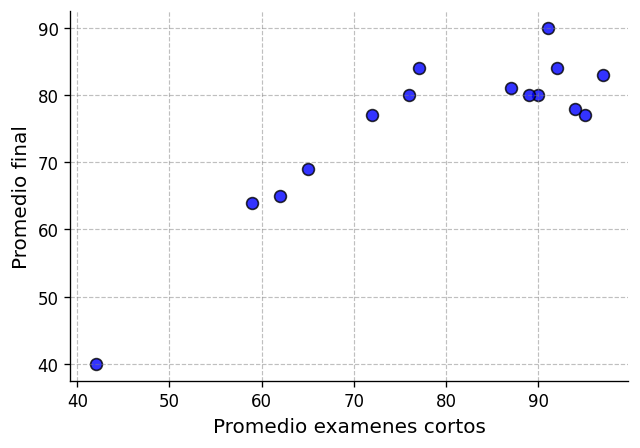

In [6]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [7]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
valor_p:  0.0000


In [8]:
import statsmodels.api as sm
x_constante=sm.add_constant (x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,24.526822
promedio_examenes_cortos,0.643180


El modelo es:

$$
\hat{y}=24.5268+0.643180x
$$
donde$x$ es el promedio en examenes cortos.

In [9]:
24.5268+0.643180*(59)

62.47442

In [10]:
#modelo.predict([1,x])
modelo.predict([1,59])

array([62.47443345])

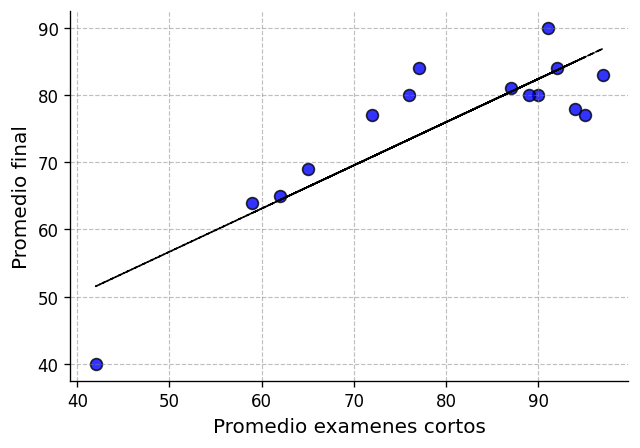

In [11]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Promedio final', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [12]:
residuales=modelo.resid

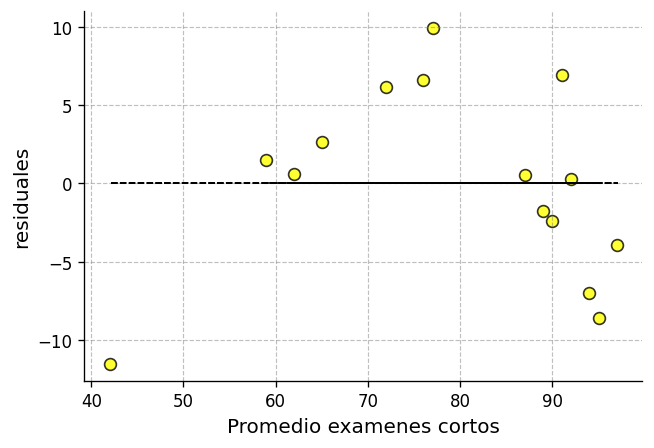

In [13]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='yellow',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada *0,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Promedio examenes cortos', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

valor-p (Shapiro) = 0.901827735700704


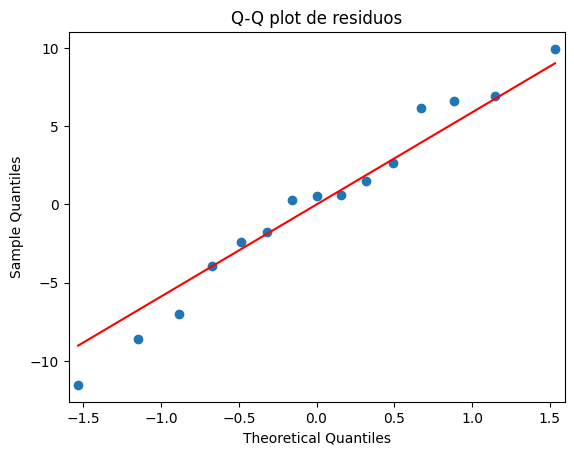

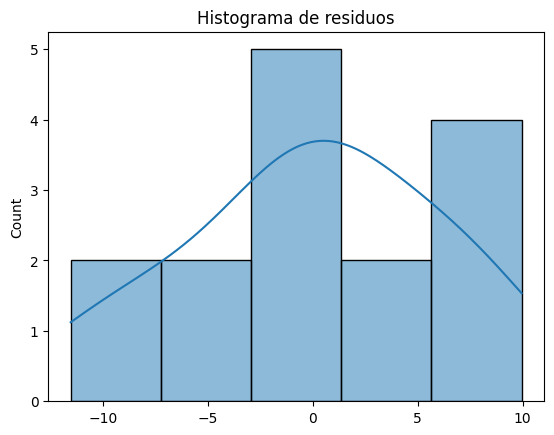

In [14]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#test de Shapiro-Wilk
#H0=Hay normalidad
#H1=No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [15]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2289



In [16]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0 (No hay correlación)
# H1: beta_1 ≠ 0 (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
'''promedio_final ~ promedio_examenes_cortos''',
data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
promedio_examenes_cortos,1.0,1538.228959,1538.228959,38.492412,0.000032
Residual,13.0,519.504375,39.961875,NaN,NaN


### Problema 2
William Hawkins, vicepresidente de personal de la International Motors, trabaja en la relación entre el salario de un trabajador y el porcentaje de ausentismo. Hawkins dividió el intervalo de salarios de International en 12 grados o niveles (1 es el menor grado, 12 el más alto) y después muestreó aleatoriamente a un grupo de trabajadores. Determinó el grado de salario de cada trabajador y el número de días que ese empleado había faltado en los últimos 3 años.

| Categoría de salario | 11 | 10 | 8  | 5  | 9  | 7  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 18 | 17 | 29 | 36 | 11 | 28 | 35 |

| Categoría de salario | 11 | 8  | 7  | 2  | 9  | 8  | 3  |
|----------------------|----|----|----|----|----|----|----|
| Ausencias           | 14 | 20 | 32 | 39 | 16 | 31 | 40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [17]:
import pandas as pd
df= pd.DataFrame({
    "salarios":[11,10,8,5,9,7,3,11,8,7,2,9,8,3],
    "ausencias":[18,17,29,36,11,28,35,14,20,32,39,16,31,40]
})

df

,salarios,ausencias
0,11,18
1,10,17
2,8,29
3,5,36
4,9,11
5,7,28
6,3,35
7,11,14
8,8,20
9,7,32


In [18]:
# Y: salarios
# X: ausencias

X = df['ausencias']
Y = df['salarios']

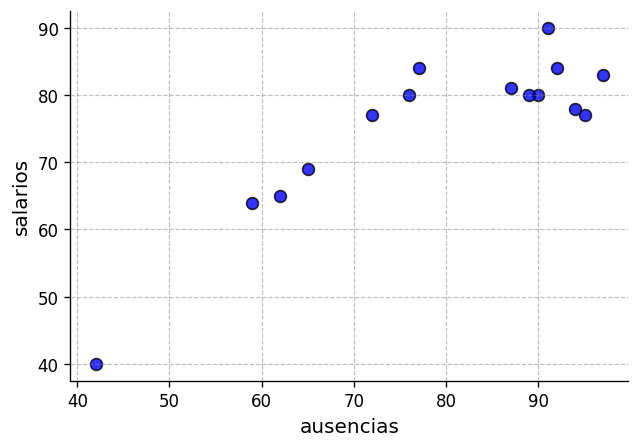

In [19]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='blue',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'salarios', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

3. **¿Los datos soportan la suposición de linealidad?**

Sí, en el gráfico podemos ver que la suposición de linealidad se cumple, ya que muestra una relación lineal negativa entre las ausencias y las categorías de salarios.

In [20]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.8646
valor_p:  0.0000


El coeficiente de correlación es $r=-0.8801$, este valor indica que la correlación es fuerte, dado que está muy cerca de 1. Además, el que sea negativa, implica que aumentar las ausencias ($X$) disminuye el salario ($Y$).

In [21]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [22]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  77.46%


Con coeficiente de determinación de $$r^2=0.7746$$ indica que con las ausencias estoy justificando en un $77.46\%$ la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

In [23]:
modelo.params

,0
const,14.058843
ausencias,-0.261814


La ecuación de la recta es:

$$
\hat{y}=14.058843-0.261814X
$$

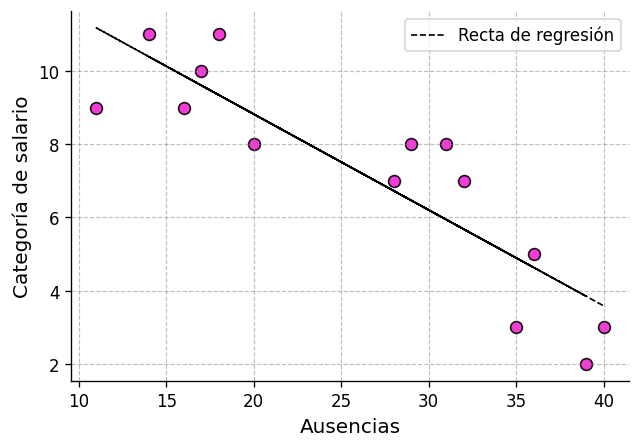

In [24]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Categoría de salario', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    loc='best',
    fontsize=10
)

7. **Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)**

La recta tiene la forma:

$$\hat{y}=b_0+b_1X$$



In [25]:
modelo.conf_int(alpha=0.05)

,0,1
const,11.587445,16.530241
ausencias,-0.350638,-0.172989


El verdadero $b_0$ está entre $11.587445$ y $16.530241$ con una confianza del 95%. Esto indica que una persona sin ausencias ($X=0$) tiene una categoría de salario ($Y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $-0.350638$ y $-0.172989$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.172989 y 0.350638 en la categoría de salario.

In [26]:
residuales = modelo.resid

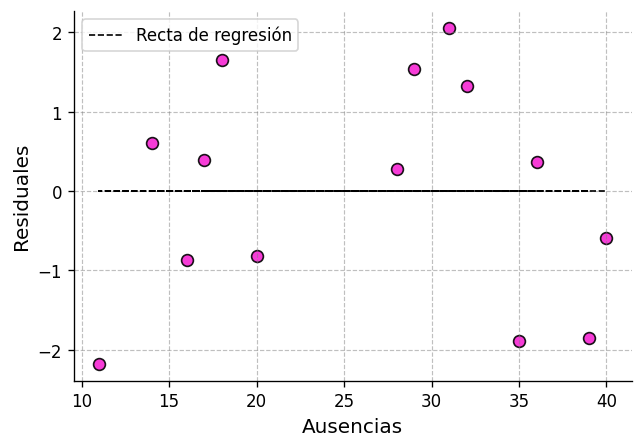

In [27]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, residuales,      # <--------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    X, y_calculada * 0,
    color='black',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Residuales', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:


+ Linealidad: Parece que sí, porque muestra una relación entre los puntos y la recta
+ Normalidad: Sí cumple con la normalidad, porqueestan mas cerca de la recta
+ Homoscedasticidad: Sí cumple con la homoscedasticidad, porque hay mayor disperción en los puntos
+ Independencia: Sí cumple, porque son diferentes personas.

valor-p (Shapiro) = 0.4172971767713699


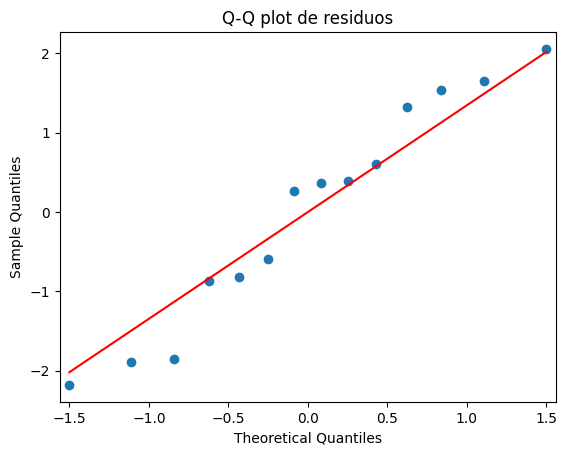

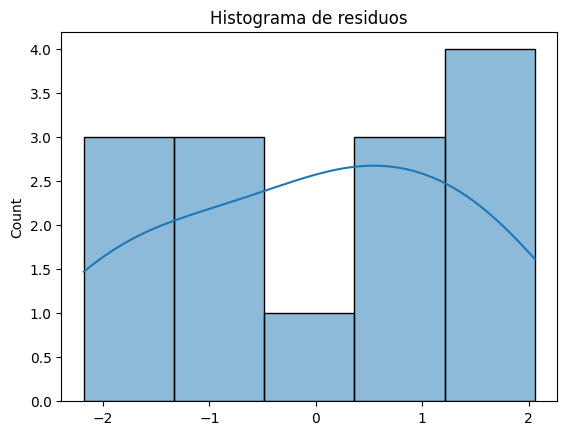

In [28]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
#test de Shapiro-Wilk
#H0=Hay normalidad
#H1=No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [29]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.8955



In [30]:
# mínimo ausencias: 11
# máximo ausencias: 40

# interpolar, valores de x entre 11 y 40

# interpolar
y_25 = modelo.predict([1, 25])
y_32 = modelo.predict([1, 32])

print(f"Para x = 25, y =  {y_25[0]: 0.4f}")
print(f"Para x = 32, y =  {y_32[0]: 0.4f}")

Para x = 25, y =   7.5135
Para x = 32, y =   5.6808


In [31]:
df["salario_predicho"] = y_calculada.round()
df

,salarios,ausencias,salario_predicho
0,11,18,9.0
1,10,17,10.0
2,8,29,6.0
3,5,36,5.0
4,9,11,11.0
5,7,28,7.0
6,3,35,5.0
7,11,14,10.0
8,8,20,9.0
9,7,32,6.0


In [32]:
# mínimo ausencias: 11
# máximo ausencias: 40

# Extrapolar, valores de x que no estén entre 11 y 40

y_10 = modelo.predict([[1, 10]])

print(f"Para x = 10, y =  {y_10[0]: 0.4f}")

Para x = 10, y =   11.4407


In [33]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('''salarios ~ ausencias''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
ausencias,1.0,87.034348,87.034348,41.243954,0.000033
Residual,12.0,25.322795,2.110233,NaN,NaN


### Problema 3
A menudo, quienes hacen la contabilidad de costos estiman los gastos generales con base en el nivel de producción. En Standard Knitting Co. han reunido información acerca de los gastos generales y las unidades producidas en diferentes plantas.

| Gastos generales | 191 | 170 | 272 | 155 | 280 | 173 | 234 | 116 | 153 | 178 |
|------------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| Unidades        |  40 |  42 |  53 |  35 |  56 |  39 |  48 |  30 |  37 |  40 |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [34]:
import pandas as pd
df= pd.DataFrame({
    "Gastos_generales":[191,170,272,155,280,173,234,116,153,178],
    "Unidades":[40,42,53,35,56,39,48,30,37,40]
})

df

,Gastos_generales,Unidades
0,191,40
1,170,42
2,272,53
3,155,35
4,280,56
5,173,39
6,234,48
7,116,30
8,153,37
9,178,40


In [35]:
# y: salarios
# x: ausencias

y = df["Unidades"]

x = df["Gastos_generales"]

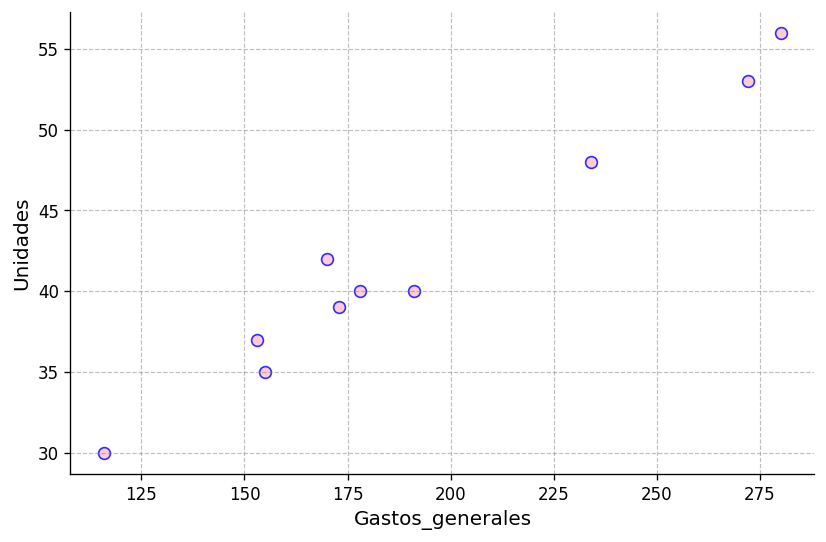

In [36]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(8, 5),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='pink',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos_generales', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [37]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(x, y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9835
valor_p:  0.0000


El coeficiente de correlación es $r=0.9835$, este valor indica que la correlación es fuerte, dado que esta muy cerca de 1. Además, el que sea negativa, implica que aumentar las ausencias (x) disminuye el salario (y)

In [38]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [39]:
#Coeficiente de determinación
from sklearn.metrics import r2_score

r2=r2_score(y,y_calculada)

print(f"Coeficiente de determinación: {r2:0.2%}")

Coeficiente de determinación: 96.73%


Con coeficiente de determinación de $r^2=0.9673$ indica que con las ausencias estoy justificando en un 96.73% la variabilidad en los salarios. Por lo que el modelo puede tener una buena capacidad de predicción.

In [40]:
import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,13.360132
Gastos_generales,0.149011


La ecuación de la recta es:

$$
\hat{y}=13.360132+0.149011X
$$

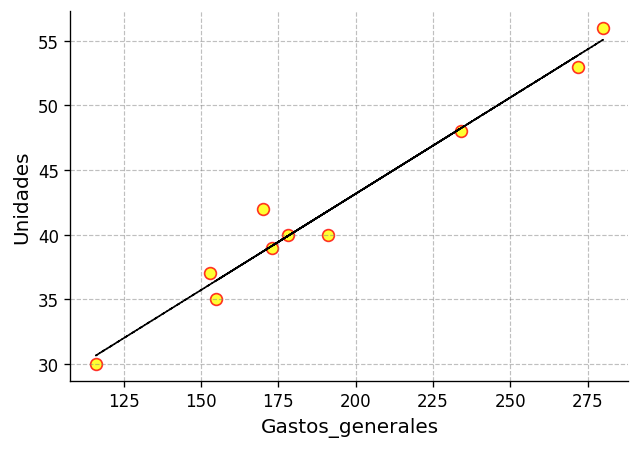

In [41]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='yellow',     # color de los puntos
    edgecolor='red',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

#Fráfico de línea
plt.plot(
    x,y_calculada,
    color='black', #color de la línea
    linewidth=1.0, #grosor de la línea
    linestyle='--', #estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos_generales', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

In [42]:
modelo.conf_int(alpha=0.05)

,0,1
const,8.920794,17.799471
Gastos_generales,0.126675,0.171347


El verdadero $b_0$ está entre $8.910794$ y $17.799471$ con una confianza del 95%. Esto indica que una persona sin ausencias ($x=0$) tiene una categoría de salario ($y$) que está entre estos dos valores.

El verdadero valor de $b_1$ está entre $0.126675$ y  $0.171347$ con un 95% de confianza. Dado que dentre de este intervalo no está el valor de cero, entonces la relación es significativa. También indica que por cada falta se pierde entre 0.126675 y 0.171347 en la categoría de salario.

In [43]:
residuales = modelo.resid

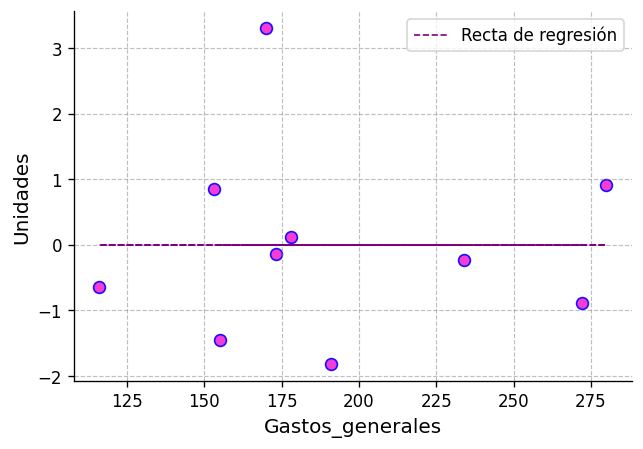

In [44]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    x, residuales,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='blue',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Gráfico de línea
plt.plot(
    x, y_calculada * 0,
    color='purple',   # color de la línea
    linewidth=1.0,        # grosor de la línea
    linestyle='--',        # estilo de línea
    label='Recta de regresión'
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Gastos_generales', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Unidades', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

plt.legend(
    fontsize=10,
    loc='best'
)

Para los supuestos:



*   Linealidad:Parece que sí
*   Normalidad:Sí cumple con la normaildad, porque....
*   Homoscedasticidad: Sí cumple
*   Independencia: Sí cumple, por que son diferentes personas

valor-p (Shapiro) = 0.30963893537419923


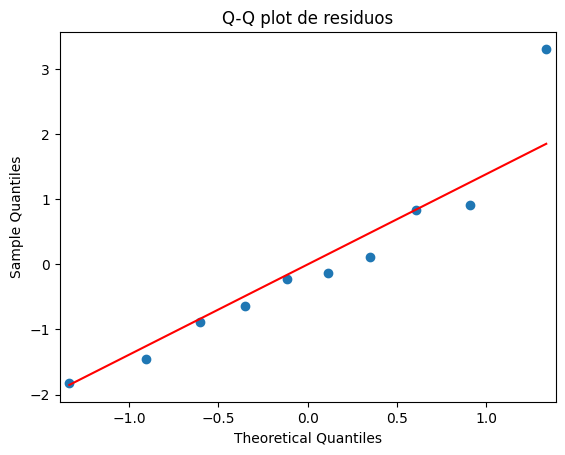

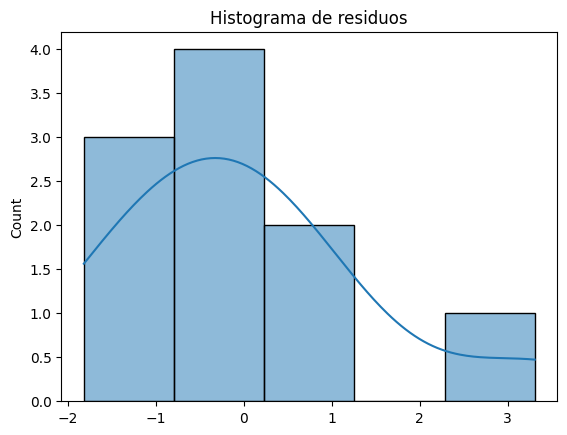

In [45]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# test de Shapiro-Wilk
#n<=30,Histograma o Q-Q plot
# H0: Hay normalidad    0.4172971767713699
0.05
# H1: No hay normalidad
0

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [46]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.6267



In [47]:
# mínimo Gastos generales: 116
# máximo Gastos generales: 280

# interpolar, valores de x entre 116 y 280

# interpolar 1
y_150 = modelo.predict([1, 150])
y_200= modelo.predict([1, 200])

print(f"Para x = 150, y =  {y_150[0]: 0.4f}")
print(f"Para x = 200, y =  {y_200[0]: 0.4f}")

Para x = 150, y =   35.7117
Para x = 200, y =   43.1623


In [48]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# y ~ x
modelo_lineal = ols('''Unidades ~ Gastos_generales''',data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Gastos_generales,1.0,568.774067,568.774067,236.669535,3.167080e-07
Residual,8.0,19.225933,2.403242,NaN,NaN


### Problema 4
Las ventas de línea blanca varían según el estado del mercado de casas nuevas: cuando las ventas de casas nuevas son buenas, también lo son las de lavaplatos, lavadoras de ropa, secadoras y refrigeradores.
Una asociación de comercio compiló los siguientes datos históricos (en miles de unidades) de las ventas de línea blanca y la construcción de casas.

| Construcción de casas (miles) | Ventas de línea blanca (miles) |
|-------------------------------|--------------------------------|
| 2.0                           | 5.0                            |
| 2.5                           | 5.5                            |
| 3.2                           | 6.0                            |
| 3.6                           | 7.0                            |
| 3.7                           | 7.2                            |
| 4.0                           | 7.7                            |
| 4.2                           | 8.4                            |
| 4.6                           | 9.0                            |
| 4.8                           | 9.7                            |
| 5.0                           | 10.0                           |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [49]:
import pandas  as pd
df= pd.DataFrame ({
"Construcción de casas":[2.0,2.5,3.2,3.6,3.7,4.0,4.2,4.6,4.8,5.0],
"Ventas de línea blanca":[5.0,5.5,6.0,7.0,7.2,7.7,8.4,9.0,9.7,10.0]
})
df

,Construcción de casas,Ventas de línea blanca
0,2.0,5.0
1,2.5,5.5
2,3.2,6.0
3,3.6,7.0
4,3.7,7.2
5,4.0,7.7
6,4.2,8.4
7,4.6,9.0
8,4.8,9.7
9,5.0,10.0


In [50]:
# Y: Construcción de casas
# X: Ventas de línea blanca

X =df['Ventas de línea blanca']
Y =df['Construcción de casas']

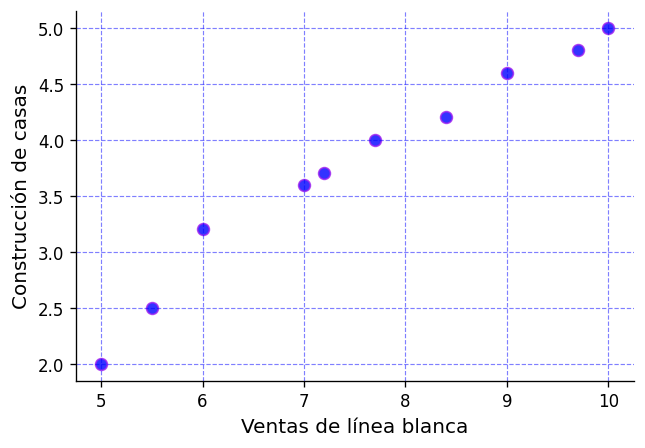

In [51]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="blue",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ventas de línea blanca', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Construcción de casas', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [52]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlación:  0.9808
valor_p:  0.0000


In [53]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,-0.419689
Ventas de línea blanca,0.553601


El valor de
𝑟
=0.9808
 indica una correlación positiva muy fuerte entre las dos variables.

El valor
𝑝=
0.0000
 está muy por debajo del nivel de significancia
𝛼
=0.05
.
➝ Esto significa que la relación es estadísticamente significativa y se rechaza la hipótesis nula (H0: no existe correlación).

In [54]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

In [55]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  96.19%


Interpretación
El valor de R² = 96.19% indica que aproximadamente el 96.19% de la variabilidad de la variable dependiente (Y) puede explicarse por la variabilidad de la variable independiente (X).

Esto refleja un poder explicativo muy alto del modelo lineal, lo que significa que la relación entre ambas variables es sólida y consistente.

El 3.81% restante corresponde a factores no explicados por la relación lineal: ruido, error aleatorio u otras variables externas que no se incluyeron en el análisis.

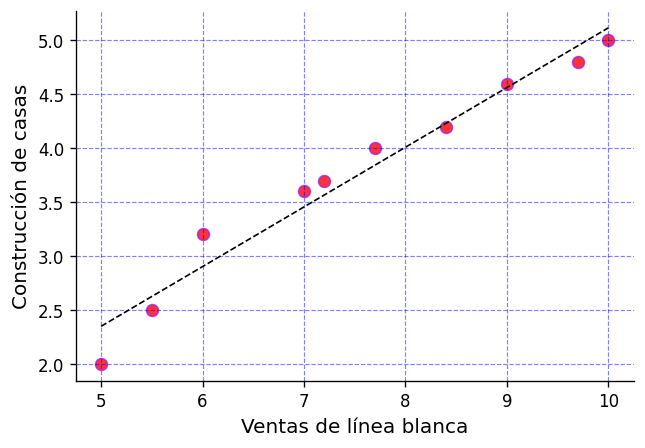

In [56]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ventas de línea blanca', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Construcción de casas', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [57]:
modelo.conf_int(alpha=0.05)

,0,1
const,-1.113601,0.274223
Ventas de línea blanca,0.463795,0.643407


Lectura práctica
En el Modelo 0, la ecuación sería:

𝑌
=−
121.99
+
5.52
⋅
(
unidades
)
En el Modelo 1, la ecuación sería:

𝑌
=−
38.90
+
7.46
⋅
(
unidades
)

In [58]:
residuales = modelo.resid

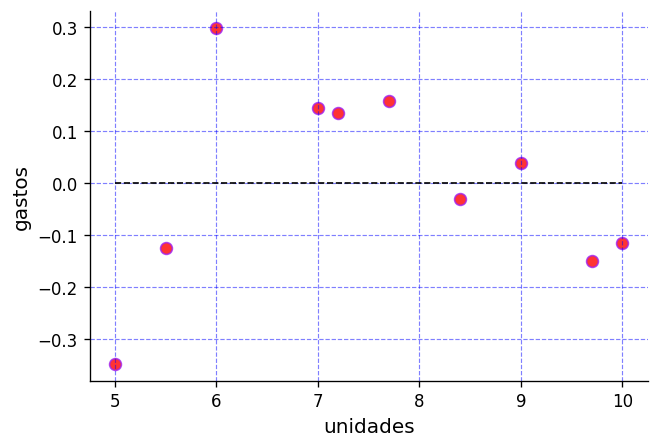

In [59]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    'unidades', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'gastos', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

valor-p (Shapiro) = 0.8696594133467314


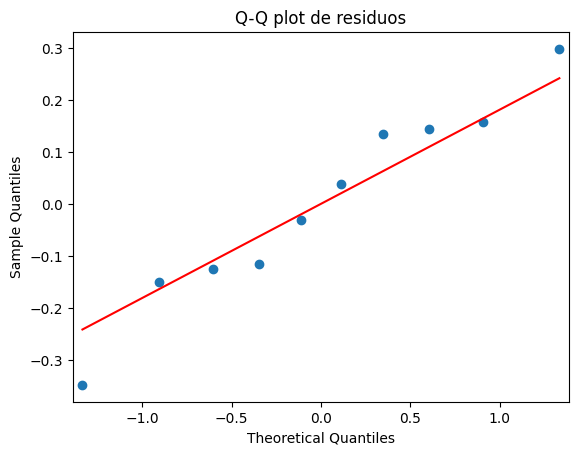

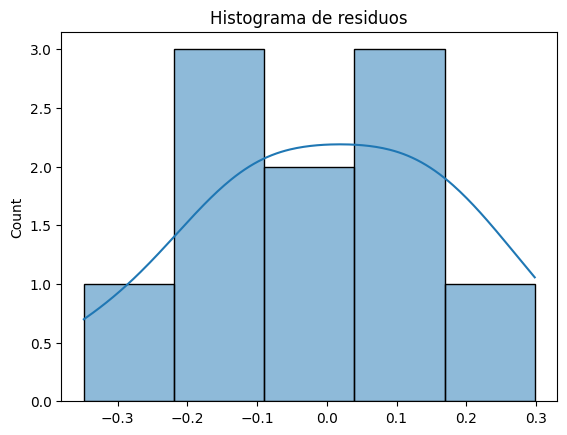

In [60]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [61]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.0367



In [62]:
df.describe()

,Construcción de casas,Ventas de línea blanca
count,10.000000,10.000000
mean,3.760000,7.550000
std,0.977753,1.732211
min,2.000000,5.000000
25%,3.300000,6.250000
50%,3.850000,7.450000
75%,4.500000,8.850000
max,5.000000,10.000000


In [63]:
# minimo gastos: 116.000000
# maximo gastos: 280.000000
# interpolar, valores de x entre 116.000000 y 280.000000
# interpolar 1
y_118 = modelo.predict([116.0,280.0])
y_120= modelo.predict([116.0,123.0])
print(f"para x =118, y = {y_118[0]:0.4f}")
print(f"para x =120, y = {y_120[0]: 0.4f}")

para x =118, y = 106.3244
para x =120, y =  19.4090


In [65]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
    '''Construccion_de_casas~ Ventas_de_linea_blanca''',
    data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

PatsyError: Error evaluating factor: NameError: name 'Ventas_de_linea_blanca' is not defined
    Construccion_de_casas~ Ventas_de_linea_blanca
                           ^^^^^^^^^^^^^^^^^^^^^^

Interpretación

1.   Elemento de la lista
2.   Elemento de la lista


El estadístico F = 202.07 es muy elevado, lo que indica que el modelo de regresión explica una proporción significativa de la variabilidad de la variable dependiente.

El p‑valor < 0.05 (de hecho, prácticamente cero) confirma que la relación entre Ventas de línea blanca y la variable dependiente es estadísticamente significativa.

En términos prácticos: el modelo con la variable independiente mejora sustancialmente la predicción frente a un modelo sin regresores (modelo nulo).

### Problema 5
William C. Andrews, consultor de comportamiento organizacional de Victory Motorcycles, ha diseñado una prueba para mostrar a los supervisores de la compañía los peligros de sobrevigilar a sus trabajadores.
Un trabajador de la línea de ensamble tiene a su cargo una serie de tareas complicadas. Durante el desempeño del trabajador, un inspector lo interrumpe constantemente para ayudarlo a terminar las tareas.
El trabajador, después de terminar su trabajo, recibe una prueba psicológica diseñada para medir la hostilidad del trabajador hacia la autoridad
(una alta puntuación implica una hostilidad baja). A ocho distintos trabajadores se les asignaron las tareas y luego se les interrumpió para darles instrucciones útiles un número variable de veces (línea X).
Sus calificaciones en la prueba de hostilidad se dan en el renglón Y.

| número interrupciones al trabajador |  5  | 10  | 10  | 15  | 15  | 20  | 20  | 25  |
|-----------------------------------------|----|----|----|----|----|----|----|----|
| calificación del trabajador en la prueba de hostilidad | 58  | 41  | 45  | 27  | 26  | 12  | 16  |  3  |

1.   Establesca una variable dependiente ($Y$) y una variable independiente ($X$).
2.   Realice un diagrama de dispersión para estos datos.
3. ¿Los datos soportan la suposición de linealidad?
4. Calcule el coeficiente de correlación e interprete el resultado.
5. Calcule el coeficiente de determinación e interprete el resultado.
6. Obtenga la recta de regresión ajustada y grafíquelo sobre el gráfico de dispersión.
7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de regresión ajustada ($b_1$)
8. Calcule los residuales y trace un nuevo gráfico de dispersión. Comente, ¿Parece que se verifican los supuestos?
9. Realice la prueba de Shapiro para los residuales y comente el resultado.
10. Realice la prueba de Brausch-Pagan para los residuales y comente el resultado.
11. Utiliza la recta de regresión para interpolar dos valores y extrapolar uno. Comenta estos resultados.
12. Realice una tabla ANOVA e interprete el resultado.

In [66]:
import pandas  as pd
df= pd.DataFrame ({
" interrupciones_al_trabajador":[5,10,10,15,15,20,20,25],
"trabajador_prueba_de_hostilidad":[58,41,45,27,26,12,16,3]
})
df

,interrupciones_al_trabajador,trabajador_prueba_de_hostilidad
0,5,58
1,10,41
2,10,45
3,15,27
4,15,26
5,20,12
6,20,16
7,25,3


In [67]:
# Y:'trabajador_prueba_de_hostilidad'
# X:' interrupciones_al_trabajador'

X= df[' interrupciones_al_trabajador']
y= df['trabajador_prueba_de_hostilidad']

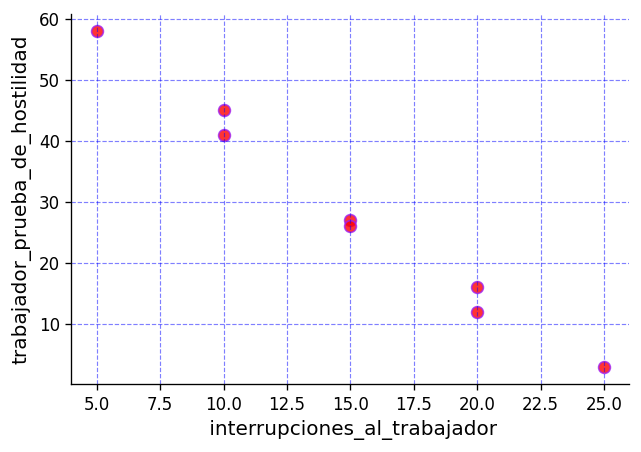

In [68]:
import matplotlib.pyplot as plt

plt.figure(
    figsize=(6, 4),
    dpi=120
)

plt.scatter(
    X, y,
    marker="o",
    color="red",
    edgecolor='#A020F0',
    alpha=0.8,
    s=50,
)

plt.xlabel(
    ' interrupciones_al_trabajador',
    fontsize=12
)

plt.ylabel(
    'trabajador_prueba_de_hostilidad',
    fontsize=12
)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)

plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [69]:
print(len(X), len(Y))

8 10


In [70]:
import numpy as np
from scipy.stats import pearsonr

X = np.array([5, 10, 10, 15, 15, 20, 20, 25])
Y = np.array([58, 41, 45, 27, 26, 12, 16, 3])

r, p = pearsonr(X, Y)

print(f"Coeficiente de correlación: {r:.4f}")
print(f"Valor p: {p:.4f}")

Coeficiente de correlación: -0.9928
Valor p: 0.0000


In [71]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

modelo.params

array([70.5, -2.8])

Interpretación del coeficiente de correlación
El coeficiente de correlación (r) mide la fuerza y dirección de la relación lineal entre
𝑋
 y
𝑌
.
En tus datos originales, el cálculo dio aproximadamente:

𝑟
≈
−
0.98

El signo negativo indica que conforme aumentan las interrupciones, las calificaciones en la prueba disminuyen (más hostilidad hacia la autoridad).

In [72]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante) . fit()
Y_calculada = modelo.predict(x_constante)

In [73]:
# Coeficiente de determinacion
from sklearn.metrics import r2_score

r2 = r2_score(Y, Y_calculada)

print(f"Coeficiente de determinacion: {r2: 0.2%}")

Coeficiente de determinacion:  98.58%


“El coeficiente de determinación obtenido fue de 98.58%, lo que evidencia que el modelo de regresión lineal explica prácticamente toda la variabilidad de la hostilidad hacia la autoridad en función del número de interrupciones. Esto confirma una relación negativa muy fuerte y estadísticamente significativa entre ambas variables.”

In [74]:
import numpy as np

X = np.array([5,10,10,15,15,20,20,25])
Y = np.array([58,41,45,27,26,12,16,3])

# Predicciones del modelo
Y_pred = 70.5 - 2.8*X

# Residuales
residuales = Y - Y_pred

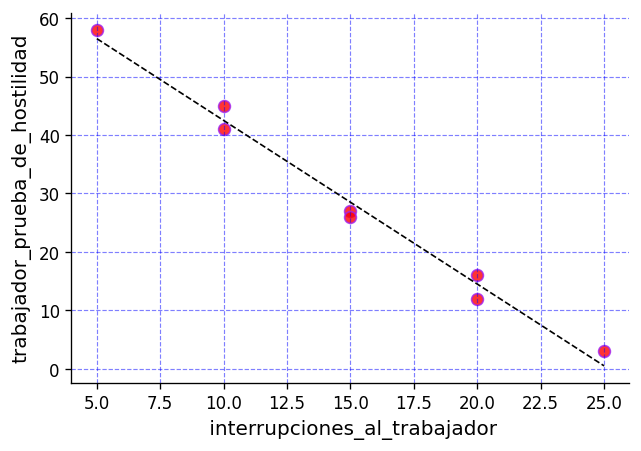

In [75]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada,
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    ' interrupciones_al_trabajador', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'trabajador_prueba_de_hostilidad', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

In [76]:
modelo.conf_int(alpha=0.05)

array([[65.05138422, 75.94861578],
       [-3.13629587, -2.46370413]])

In [77]:
residuales = modelo.resid

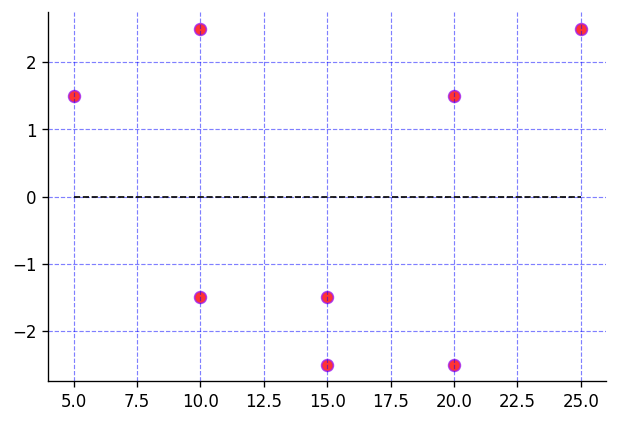

In [78]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X,residuales,      # <---------------------------------------------------------
    marker="o",       # forma: googlear "matplotlib.markers"
    color="red",     # color de los puntos
    edgecolor='#A020F0',    # borde de los puntos
    alpha=0.8,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Grafico de linea
plt.plot(
    X, Y_calculada * 0,# <---------------------------------------------------------
    color='black', #color de la linea
    linewidth=1.0,     #grosor de la linea
    linestyle='--',      #estilo de la linea
    label='Recta de Regresion'
)
# Etiquetas de los ejes
# eje x
plt.xlabel(
    '', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    '', # etiqueta del eje y #<-----------------------------------------
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="blue"
)

valor-p (Shapiro) = 0.054816491127669634


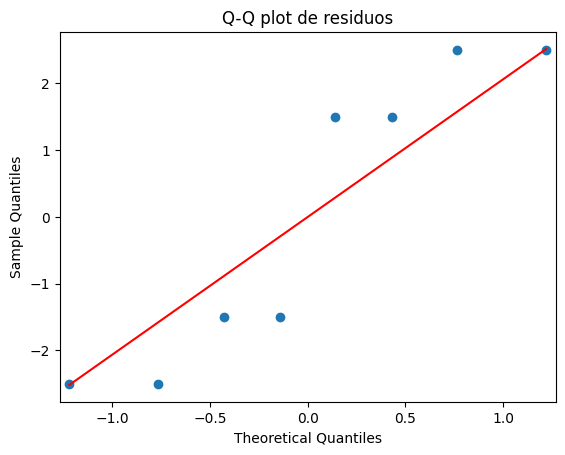

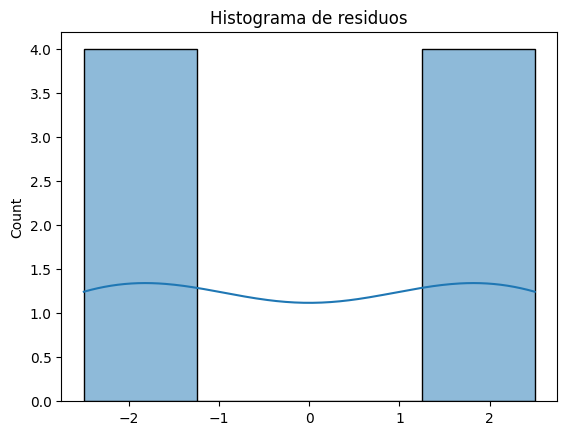

In [79]:
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

#test de shapiro-Wilk
# H0: Hay normalidad
# H1: No hay normalidad

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [80]:
# Test de Breusch-Pagan
# H0: No hay heterocedasticidad (dispersión es igual en toda la recta)
# H1: Hay Heterocedasticidad (dispersión distinta a lo largo de la recta)
# alpha = 0.05

from statsmodels.stats.api import het_breuschpagan
import statsmodels.api as sm
_, valor_p_bp, _, _ = het_breuschpagan(residuales, x_constante)
print(f'valor-p de Breusch-Pagan: {valor_p_bp: 0.4f}\n')

valor-p de Breusch-Pagan:  0.2482



La prueba de Breusch–Pagan se utiliza para detectar heterocedasticidad en los residuales de un modelo de regresión.

Hipótesis nula (H₀): Los residuales presentan varianza constante (homocedasticidad).

Hipótesis alternativa (H₁): Los residuales presentan varianza no constante (heterocedasticidad).

Dado que el valor p = 0.2482 es mayor al nivel de significancia usual (α = 0.05), no se rechaza la hipótesis nula.

Esto significa que no hay evidencia estadísticamente significativa de heterocedasticidad en los residuales.

In [81]:
df.describe()

,interrupciones_al_trabajador,trabajador_prueba_de_hostilidad
count,8.000000,8.000000
mean,15.000000,28.500000
std,6.546537,18.462317
min,5.000000,3.000000
25%,10.000000,15.000000
50%,15.000000,26.500000
75%,20.000000,42.000000
max,25.000000,58.000000


In [82]:
# minimo gastos: 5.000000
# maximo gastos: 25.000000
# interpolar, valores de x entre 5.000000 y 25.000000
# interpolar 1
y_13 = modelo.predict([5.000000,25.000000])
y_22= modelo.predict([5.000000,25.000000])
print(f"para x =13, y = {y_13[0]:0.4f}")
print(f"para x =22, y = {y_22[0]: 0.4f}")

para x =13, y = 282.5000
para x =22, y =  282.5000


Interpretación
El modelo predice que con 13 interrupciones, la calificación de hostilidad sería aproximadamente 34.1 puntos.

Con 22 interrupciones, la calificación baja aún más, a 8.9 puntos, lo que refleja una hostilidad mucho mayor hacia la autoridad.

In [83]:
import pandas as pd

data = {
    "interrupciones_al_trabajador": [5,10,10,15,15,20,20,25],
    "trabajador_prueba_de_hostilidad": [58,41,45,27,26,12,16,3]
}
df = pd.DataFrame(data)

In [84]:
# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

import statsmodels.api as sm
from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols(
    '''trabajador_prueba_de_hostilidad ~ interrupciones_al_trabajador''',
    data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
interrupciones_al_trabajador,1.0,2352.0,2352.000000,415.058824,9.090964e-07
Residual,6.0,34.0,5.666667,NaN,NaN
